# Übung 3 – Spickzettel: neue Befehle

Dieser Spickzettel dient nur als kurze Einführung vor der Übung.  
Er verwendet keine Daten und keine Aufgaben aus der eigentlichen Übung.

Die Erklärungen stehen in Markdown-Zellen. Die Code-Zellen darunter können einzeln ausgeführt werden.


## 1. Neue Bibliothek: TESPy

**TESPy** wird verwendet, um thermodynamische Systeme als Netzwerk aus Komponenten und Verbindungen aufzubauen.  
Man erstellt zuerst ein Netzwerk, fügt Komponenten hinzu, verbindet diese Komponenten und lässt TESPy anschließend das Gleichungssystem lösen.

Die folgende Installationszelle ist nur nötig, falls TESPy in der aktuellen Umgebung noch nicht installiert ist.


In [1]:
# Installiert TESPy in der aktuellen Notebook-Umgebung, falls es noch nicht vorhanden ist.
%pip install tespy


Note: you may need to restart the kernel to use updated packages.


## 2. TESPy-Importe

Aus TESPy werden keine einzelnen Funktionen wie bei `numpy` importiert, sondern Klassen.  
Eine Klasse ist eine Art Vorlage, aus der später konkrete Objekte erzeugt werden, zum Beispiel eine Pumpe oder eine Turbine.


In [3]:
from tespy.networks import Network  # Klasse für das gesamte thermodynamische Netzwerk

from tespy.components import (  # Klassen für typische Komponenten eines Anlagenmodells
    CycleCloser,  # schließt einen Kreisprozess in TESPy
    Pump,  # Pumpe
    Condenser,  # Kondensator
    Turbine,  # Turbine
    SimpleHeatExchanger,  # einfacher Wärmeübertrager
    Source,  # Quelle, also Eintritt von außen in das Modell
    Sink,  # Senke, also Austritt aus dem Modell
)

from tespy.connections import Connection  # Klasse für Stoffstrom-Verbindungen zwischen Komponenten


## 3. Netzwerk und Komponenten erzeugen

Ein TESPy-Modell beginnt meistens mit einem leeren Netzwerk. Danach werden Komponenten als Python-Variablen gespeichert.  
Die Namen in Anführungszeichen sind nur Beschriftungen im TESPy-Modell.


In [5]:
netz = Network()  # erstellt ein leeres TESPy-Netzwerk

netz.units.set_defaults(
    temperature="°C",          # Temperaturen in °C
    pressure="bar",            # Drücke in bar
    pressure_difference="bar", # Druckdifferenzen in bar
    enthalpy="kJ / kg",        # Enthalpien in kJ/kg
)

quelle = Source("Quelle")  # erzeugt eine Quelle mit dem Namen "Quelle"
senke = Sink("Senke")  # erzeugt eine Senke mit dem Namen "Senke"
waermetauscher = SimpleHeatExchanger("Wärmeübertrager")  # erzeugt einen einfachen Wärmeübertrager
pumpe = Pump("Pumpe")  # erzeugt eine Pumpe
kreis_schliesser = CycleCloser("Kreisschließer")  # wird verwendet, um einen geschlossenen Kreisprozess zu modellieren


## 4. Komponenten verbinden

Mit `Connection(...)` wird eine Verbindung zwischen zwei Komponenten erzeugt.  
Die Anschlussnamen wie `"out1"` und `"in1"` kommen aus TESPy und beschreiben Ein- und Ausgänge der Komponenten.


In [6]:
c1 = Connection(  # erzeugt eine neue Verbindung
    quelle,  # Startkomponente der Verbindung
    "out1",  # Ausgang der Startkomponente
    waermetauscher,  # Zielkomponente der Verbindung
    "in1",  # Eingang der Zielkomponente
    label="1",  # Name/Beschriftung der Verbindung
)

c2 = Connection(waermetauscher, "out1", senke, "in1", label="2")  # kurze Schreibweise für eine zweite Verbindung

netz.add_conns(c1, c2)  # fügt die Verbindungen zum TESPy-Netzwerk hinzu


## 5. Parameter mit `set_attr(...)` setzen

Mit `set_attr(...)` werden Eigenschaften von Komponenten oder Verbindungen festgelegt.  
Der gleiche Befehl wird in TESPy an vielen Stellen verwendet; wichtig sind daher vor allem die Parameter in der Klammer.


In [7]:
waermetauscher.set_attr(pr=1)  # pr ist das Druckverhältnis; pr=1 bedeutet hier: kein Druckverlust
pumpe.set_attr(eta_s=0.90)  # eta_s ist der isentrope Wirkungsgrad; 0.90 bedeutet 90 %

c1.set_attr(  # setzt Eigenschaften der Verbindung c1
    T=120,  # Temperatur des Stoffstroms
    p=5,  # Druck des Stoffstroms
    m=1.2,  # Massenstrom
    fluid={"water": 1},  # Fluidzusammensetzung; hier 100 % Wasser
)

c2.set_attr(p=None)  # None entfernt eine vorher gesetzte Vorgabe; TESPy darf diesen Wert dann selbst berechnen


## 6. Modell lösen und Ergebnisse ausgeben

Diese Befehle werden normalerweise erst verwendet, wenn das TESPy-Modell vollständig aufgebaut ist.  
Sie stehen hier deshalb als Syntax-Beispiel und sollten nicht auf das unvollständige Mini-Beispiel oben angewendet werden.

```python
netz.set_attr(iterinfo=False)  # schaltet ausführliche Iterationsinformationen aus
netz.solve(mode="design")  # löst das Modell im Auslegungsmodus
netz.print_results()  # gibt die berechneten Ergebnisse tabellarisch aus
```

`mode="design"` bedeutet: TESPy berechnet einen festgelegten Auslegungspunkt des Systems.


## 7. Elektrische Leistung: PowerBus und PowerConnection

In Übung 3 werden nicht nur Stoffströme verbunden, sondern auch Leistungsflüsse.  
Dafür gibt es eigene TESPy-Komponenten und eigene Verbindungen.


In [8]:
from tespy.components import PowerBus, PowerSink, Motor, Generator  # Komponenten für elektrische Leistung
from tespy.connections import PowerConnection  # Verbindung für Leistungsflüsse

turbine = Turbine("Turbine")  # Beispielkomponente, die Leistung abgeben kann
generator = Generator("Generator")  # wandelt mechanische Leistung in elektrische Leistung um
stromnetz = PowerBus("Strombus", num_in=1, num_out=1)  # Sammelpunkt mit 1 Eingang und 1 Ausgang
verbraucher = PowerSink("Verbraucher")  # Senke für elektrische Leistung
motor = Motor("Motor")  # wandelt elektrische Leistung in mechanische Leistung um

p1 = PowerConnection(turbine, "power", generator, "power_in", label="p1")  # Leistungsfluss von Turbine zu Generator
p2 = PowerConnection(generator, "power_out", stromnetz, "power_in1", label="p2")  # Generator speist in das Stromnetz ein
p3 = PowerConnection(stromnetz, "power_out1", verbraucher, "power", label="p3")  # Stromnetz gibt Leistung an Verbraucher ab

generator.set_attr(eta=0.95)  # eta ist der Wirkungsgrad des Generators
p3.set_attr(E=None)  # E=None bedeutet: Diese Leistung soll von TESPy berechnet werden


## 8. TESPy-Ergebnisse weiterverwenden

TESPy-Ergebnisse stehen oft in Objekten und der eigentliche Zahlenwert steckt in `.val`.  
In der Übung wird das zum Beispiel für Leistungen, Wärmeströme oder Energiebilanzen verwendet.

```python
W_net = e7.E.val  # liest den berechneten Leistungswert der Verbindung e7 aus
Q_in = sg.Q.val  # liest den berechneten Wärmestrom des Wärmeübertragers sg aus
```

Die folgenden kleinen Python-Schreibweisen kommen dabei ebenfalls vor.


In [9]:
leistung = -2_500_000  # Beispielwert; das Minuszeichen kann eine Richtung des Leistungsflusses beschreiben
waerme = 7_000_000  # Beispielwert für zugeführte Wärme

wirkungsgrad = abs(leistung) / waerme  # abs(...) macht aus einem negativen Wert den positiven Betrag

print(f"Wirkungsgrad: {round(wirkungsgrad * 100, 2)} %")  # f"..." setzt Variablen in Text ein; round(..., 2) rundet auf 2 Nachkommastellen

verlustleistung = 400e3 


Wirkungsgrad: 35.71 %


## 9. Excel-Dateien mit `pd.read_excel(...)` einlesen

In Übung 3 wird zusätzlich zu CSV-Dateien auch eine Excel-Datei eingelesen.  
Der Befehl ist hier nur als Syntax gezeigt, damit keine echten Übungsdaten benötigt werden.

```python
df = pd.read_excel("datei.xlsx", sheet_name="Tabelle1")  # liest das Tabellenblatt "Tabelle1" aus einer Excel-Datei ein
```

`sheet_name` gibt an, welches Tabellenblatt aus der Excel-Datei gelesen werden soll.


## 10. Punktepaare mit `zip(...)` bilden

Für Diagramme werden manchmal x- und y-Werte zu Punkten zusammengefasst.  
`zip(...)` nimmt jeweils den ersten x-Wert und den ersten y-Wert, dann den zweiten x-Wert und den zweiten y-Wert usw.


In [10]:
entropie = [0.5, 2.0, 4.0, 6.0]  # Beispielwerte für die x-Achse
temperatur = [30, 150, 300, 380]  # Beispielwerte für die y-Achse
labels = ["A", "B", "C", "D"]  # Beschriftungen für die Punkte

punkte = list(zip(entropie, temperatur))  # erzeugt Punktepaare: [(0.5, 30), (2.0, 150), ...]

punkte  # zeigt die erzeugten Punktepaare im Notebook an


[(0.5, 30), (2.0, 150), (4.0, 300), (6.0, 380)]

## 11. Matplotlib-Stil und zusätzliche Plot-Befehle

Die folgenden Befehle gehen über einfache Linien- und Balkendiagramme hinaus.  
Sie werden vor allem verwendet, um T-s-Diagramme zu gestalten und zu speichern.


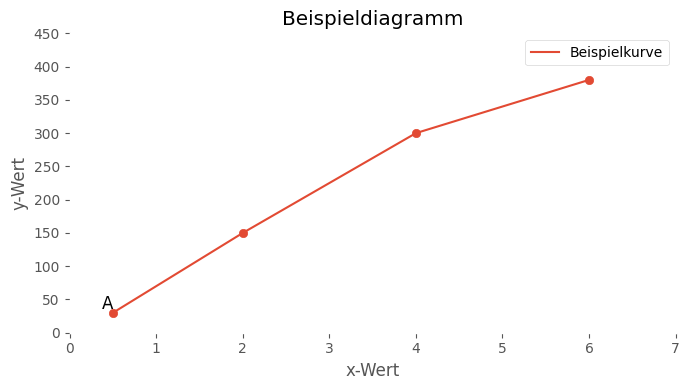

In [11]:
import matplotlib.pyplot as plt  # aus Übung 1 bekannt, hier für direkte Matplotlib-Befehle genutzt
import matplotlib.style as mplstyle  # stellt Stilvorlagen für Diagramme bereit

with mplstyle.context("ggplot", after_reset=False):  # nutzt den Stil "ggplot" nur innerhalb dieses Blocks
    plt.figure(figsize=(7, 4))  # erstellt eine neue Abbildung; figsize=(Breite, Höhe) in Zoll
    plt.rcParams["axes.facecolor"] = "white"  # setzt den Hintergrund der Achsen auf weiß

    plt.plot(entropie, temperatur, label="Beispielkurve")  # zeichnet eine Linie aus x- und y-Werten
    plt.scatter(entropie, temperatur)  # zeichnet einzelne Punkte an den x- und y-Positionen
    plt.text(entropie[0], temperatur[0], "A", fontsize=12, ha="right", va="bottom")  # schreibt Text an eine bestimmte Position

    plt.xlim(0, 7)  # legt den sichtbaren Bereich der x-Achse fest
    plt.ylim(0, 450)  # legt den sichtbaren Bereich der y-Achse fest
    plt.xlabel("x-Wert")  # Beschriftung der x-Achse
    plt.ylabel("y-Wert")  # Beschriftung der y-Achse
    plt.title("Beispieldiagramm")  # Titel des Diagramms
    plt.legend()  # zeigt die Legende an
    plt.grid(True)  # schaltet ein Gitternetz ein
    plt.tight_layout()  # passt Abstände automatisch an
    plt.savefig("beispieldiagramm.svg", format="svg", dpi=300)  # speichert die Grafik als SVG-Datei mit 300 dpi
    plt.show()  # zeigt die Grafik an


## 12. Punkte in einer Schleife beschriften

`enumerate(...)` wurde schon grundsätzlich verwendet. Neu ist hier das typische Muster, um Punkte in einem Diagramm automatisch zu beschriften.


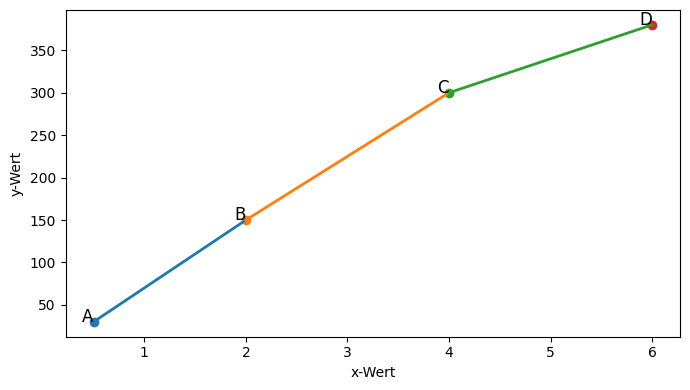

In [12]:
plt.figure(figsize=(7, 4))  # neue Abbildung

for i, (x, y) in enumerate(punkte):  # i ist die laufende Nummer; x und y sind die Koordinaten des aktuellen Punkts
    plt.scatter(x, y)  # zeichnet den aktuellen Punkt
    plt.text(x, y, labels[i], fontsize=12, ha="right")  # schreibt das passende Label an den Punkt

for i in range(len(punkte) - 1):  # läuft von Punkt 0 bis zum vorletzten Punkt
    plt.plot(  # verbindet jeweils zwei benachbarte Punkte mit einer Linie
        [punkte[i][0], punkte[i + 1][0]],  # x-Werte der beiden Punkte
        [punkte[i][1], punkte[i + 1][1]],  # y-Werte der beiden Punkte
        linestyle="-",  # Linienstil; "-" bedeutet durchgezogene Linie
        linewidth=2,  # Liniendicke
    )

plt.xlabel("x-Wert")
plt.ylabel("y-Wert")
plt.tight_layout()
plt.show()


## 13. Mehrere Diagramme in einem Raster

In der Parameterstudie werden mehrere Diagramme gleichzeitig erzeugt.  
Dafür wird ein Raster aus Achsen erstellt und anschließend in eine einfache Liste umgewandelt.


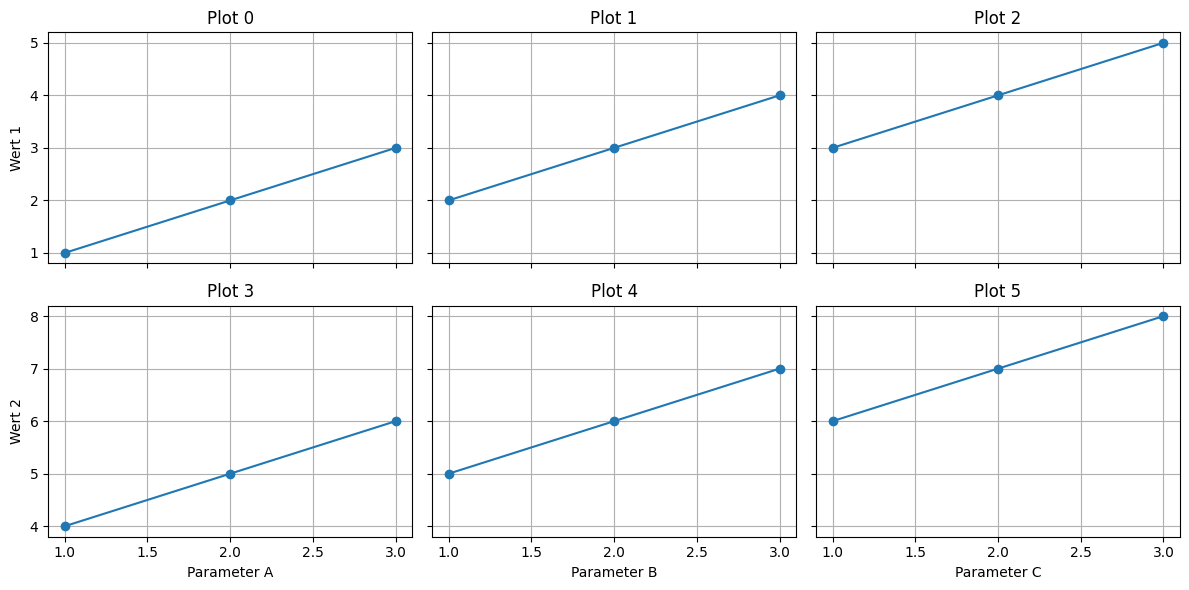

In [ ]:
fig, ax = plt.subplots(  # erstellt mehrere Teilplots in einer Abbildung
    2,  # Anzahl der Zeilen
    3,  # Anzahl der Spalten
    figsize=(12, 6),  # Gesamtgröße der Abbildung
    sharex="col",  # Teilplots in derselben Spalte teilen sich die x-Achse
    sharey="row",  # Teilplots in derselben Zeile teilen sich die y-Achse
)

ax = ax.flatten()  # macht aus dem 2x3-Achsenraster eine einfache Liste mit 6 Achsen

for a in ax:  # läuft über alle Achsen in der Liste
    a.grid(True)  # schaltet in jedem Teilplot ein Gitternetz ein

for i, a in enumerate(ax):  # i = laufende Nummer des Teilplots
    a.plot([1, 2, 3], [i + 1, i + 2, i + 3], marker="o") # befüllt alle Teilplots mit Werten
    a.set_title(f"Plot {i}")

ax[0].set_ylabel("Wert 1")  # y-Achsenbeschriftung des ersten Teilplots
ax[3].set_ylabel("Wert 2")  # y-Achsenbeschriftung des vierten Teilplots
ax[3].set_xlabel("Parameter A")  # x-Achsenbeschriftung des vierten Teilplots
ax[4].set_xlabel("Parameter B")  # x-Achsenbeschriftung des fünften Teilplots
ax[5].set_xlabel("Parameter C")  # x-Achsenbeschriftung des sechsten Teilplots

plt.tight_layout()  # verhindert überlappende Beschriftungen
plt.show()  # zeigt die gesamte Abbildung an


## 14. Ergebnisse in Dictionaries sammeln

Für Parameterstudien werden mehrere Ergebnislisten benötigt.  
Dictionaries sind dafür praktisch, weil man Werte unter einem Namen speichern kann.


In [15]:
daten = {  # Dictionary mit Beispiel-Parametern
    "Temperatur": [330, 360, 390],  # Liste mit Beispielwerten für Temperatur
    "Druck": [70, 100, 130],  # Liste mit Beispielwerten für Druck
}

ergebnis = {  # Dictionary mit leeren Listen für spätere Ergebnisse
    "Temperatur": [],  # hier werden Ergebnisse zur Temperaturvariation gesammelt
    "Druck": [],  # hier werden Ergebnisse zur Druckvariation gesammelt
}

for T in daten["Temperatur"]:  # läuft über alle Temperaturwerte
    ergebnis["Temperatur"] += [T / 10]  # hängt einen neuen Ergebniswert an die Liste an

for key in daten:  # läuft über die Schlüssel des Dictionaries, hier "Temperatur" und "Druck"
    print(key, daten[key])  # gibt den Namen des Parameters und die zugehörigen Werte aus


Temperatur [330, 360, 390]
Druck [70, 100, 130]


## 15. Mini-Zusammenfassung der neuen Befehle

| Befehl | Bedeutung |
|---|---|
| `Network()` | erzeugt ein TESPy-Netzwerk |
| `.units.set_defaults(...)` | legt Standardeinheiten im Netzwerk fest |
| `Pump(...)`, `Turbine(...)`, `Condenser(...)` | erzeugen TESPy-Komponenten |
| `Connection(...)` | verbindet zwei TESPy-Komponenten über einen Stoffstrom |
| `.add_conns(...)` | fügt Verbindungen zum Netzwerk hinzu |
| `.set_attr(...)` | setzt Eigenschaften von Komponenten oder Verbindungen |
| `.solve(mode="design")` | löst das TESPy-Modell im Auslegungsmodus |
| `.print_results()` | gibt TESPy-Ergebnisse aus |
| `PowerBus(...)` | sammelt oder verteilt Leistungsflüsse |
| `PowerConnection(...)` | verbindet Leistungsanschlüsse |
| `.val` | liest den Zahlenwert eines TESPy-Ergebnisses aus |
| `pd.read_excel(...)` | liest eine Excel-Datei ein |
| `with mplstyle.context(...)` | nutzt vorübergehend einen Diagrammstil |
| `plt.text(...)` | schreibt Text in ein Diagramm |
| `plt.xlim(...)`, `plt.ylim(...)` | setzen die sichtbaren Achsenbereiche |
| `plt.savefig(...)` | speichert eine Grafik als Datei |
| `zip(...)` | kombiniert zwei Listen zu Wertepaaren |
| `ax.flatten()` | macht aus einem Achsenraster eine einfache Liste |


## Ende

Dieser Spickzettel zeigt nur die grundlegende Bedienung der wichtigsten Funktionen.  
Die eigentliche Anwendung auf reale Daten passiert erst in der Übung.